# To do:
*


### Imports

In [1]:
import pandas as pd
import polars as pl
import os
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)

pl.Config(tbl_rows=20)

In [2]:
import re
from typing import List, Set, Dict
import copy

In [3]:
#from google.colab import drive
#drive.mount('/content/gdrive')
eval_loc = r'/content/gdrive/My Drive/Colab Notebooks/data/grad_student_eval/'

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Definitions

In [8]:
def clean_award_data(df):
  ''' Clean titles:
    - All lower case
    - Removes years from some titles, e.g. "(2021)"
    Expects columns:
      award: containing name of award (e.g. "best picture")
      status: winner or nominated
      year: int of year the movie was released (not award show date)
      title: title of movie

  '''

  # lowercase and normalize strings
  for col in df.columns:
    if df[col].dtype == 'O':
      df.loc[:,col] = df[col].str.lower()
      df.loc[:,col] = df[col].str.replace(r'\s*\(\d{4}\)\s*', '', regex=True).str.strip()
      df.loc[:,col] = df[col].str.normalize('NFKD')

  def normalize_values(series):
    map_dict = {'drama': 'best picture - drama',
                'best motion picture - drama': 'best picture - drama',
                'best motion picture - musical or comedy': 'best picture - musical or comedy',
                'comedy/musical': 'best picture - musical or comedy',
                'nominee':'nominated',
                'won':'winner'}
    return series.apply(lambda row: map_dict.get(row, row))
  if 'category' in df.columns:
    df.loc[:,'category'] = normalize_values(df['category'])
  if 'status' in df.columns:
    df.loc[:,'status'] = normalize_values(df['status'])
  return df

### Load GSheets data

In [9]:
gg_data = gc.open('Kalshi oscar data')

NameError: name 'gc' is not defined

In [ ]:
sheets = gg_data.worksheets()
dfs_from_sheets = {}

for sheet in sheets:
    print(f"Reading sheet: {sheet.title}")
    df = pd.DataFrame(sheet.get_all_records())
    dfs_from_sheets[sheet.title] = df

In [ ]:
gg_golden_data = (dfs_from_sheets['golden_globes']
                    .query('year >=2000 and category in ("Best Motion Picture - Drama", "Best Motion Picture - Musical or Comedy")'))


## Evals

### Golden Globes

#### Load Claude data

In [ ]:
picture_loc = eval_loc + 'picture/'
claude = {}
gemini = {}
claude['haiku'] = pd.read_csv(picture_loc + 'claude_haiku_4.5_gg_picture_y6.tsv', sep = '\t')
claude['sonnet'] = pd.read_csv(picture_loc + 'claude_sonnet_4.5_gg_picture_y6.tsv', sep = '\t')
claude['opus'] = pd.read_csv(picture_loc + 'claude_opus_4.5_gg_picture_y6.tsv', sep = '\t')
gemini['thinking'] = pd.read_csv(picture_loc + 'gemini_thinking_3_gg_picture_y6.tsv', sep = '\t')
gemini['fast1'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample1.tsv', sep = '\t')
gemini['fast2'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample2.tsv', sep = '\t')


for df in claude.values():
  df['llm_result'] = True
for df in gemini.values():
  df['llm_result'] = True

In [ ]:
for df in claude.values():
  df = clean_award_data(df)
for df in gemini.values():
  df = clean_award_data(df)
gg_golden_data = clean_award_data(gg_golden_data)

### Merge and eval

In [ ]:
haiku_merge = gg_golden_data.merge(claude['haiku'], on = ('year', 'status', 'award', 'title'), how = 'left')
opus_merge = gg_golden_data.merge(claude['opus'], on = ('year', 'status', 'award', 'title'), how = 'left')
sonnet_merge = gg_golden_data.merge(claude['sonnet'], on = ('year', 'status', 'award', 'title'), how = 'left')
sonnet_shift = claude['sonnet'].copy()
sonnet_shift['year'] = sonnet_shift['year'] + 1
sonnet_merge_shift = gg_golden_data.merge(sonnet_shift, on = ('year', 'status', 'award', 'title'), how = 'left')
opus_merge = gg_golden_data.merge(claude['opus'], on = ('year', 'status', 'award', 'title'), how = 'left')
opus_shift = claude['opus'].copy()
opus_shift['year'] = opus_shift['year'] + 1
opus_merge_shift = gg_golden_data.merge(opus_shift, on = ('year', 'status', 'award', 'title'), how = 'left')
thinking_merge = gg_golden_data.merge(gemini['thinking'], on = ('year', 'status', 'award', 'title'), how = 'left')
fast_merge1 = gg_golden_data.merge(gemini['fast1'], on = ('year', 'status', 'award', 'title'), how = 'left')
fast_merge2 = gg_golden_data.merge(gemini['fast2'], on = ('year', 'status', 'award', 'title'), how = 'left')

In [ ]:
print(haiku_merge['llm_result'].sum() / len(haiku_merge))
print(sonnet_merge['llm_result'].sum() / len(sonnet_merge))
print(sonnet_merge_shift.query('year>=2001')['llm_result'].sum() / len(sonnet_merge))
print(opus_merge['llm_result'].sum() / len(opus_merge))
print(opus_merge_shift.query('year>=2001')['llm_result'].sum() / len(opus_merge))
print('gemini')
print(fast_merge1['llm_result'].sum() / len(fast_merge1))
print(fast_merge2['llm_result'].sum() / len(fast_merge2))
print(thinking_merge['llm_result'].sum() / len(thinking_merge))

0.4591439688715953
0.0
0.9027237354085603
0.9494163424124513
0.0
gemini
0.48249027237354086
0.9494163424124513
0.9455252918287937


Missed two films because there were 7 nominees rather than 5

In [ ]:
sonnet_shift.query('year == 2008 and award == "best motion picture - drama"')

,year,winner,award,title,llm_result
71,2008,winner,best motion picture - drama,atonement,True
72,2008,nominee,best motion picture - drama,american gangster,True
73,2008,nominee,best motion picture - drama,eastern promises,True
74,2008,nominee,best motion picture - drama,the great debaters,True
75,2008,nominee,best motion picture - drama,michael clayton,True


## Box office data

### Canonical data
Load TMDB movie box office data
Need to join the eval to the input list

In [ ]:
tmdb_pdf = pd.read_csv(eval_loc + 'boxoffice/tmdb_2000_2024.csv', sep = ',')
money_cols = ['worldwide', 'domestic', 'foreign']
input_pdf = pd.read_csv(eval_loc + 'boxoffice/grad_student_boxoffice_input.tsv', sep = '\t')
input_pdf = clean_award_data(input_pdf)

In [ ]:
eval_pdf = tmdb_pdf[['Release Group', '$Worldwide', '$Domestic', '$Foreign', 'Year']]
eval_pdf = clean_award_data(eval_pdf)
eval_pdf.columns = ['title', 'worldwide', 'domestic', 'foreign', 'year']
eval_pdf = eval_pdf.merge(input_pdf, on = ['title', 'year'], how = 'inner')
for col in money_cols:
  eval_pdf.loc[:,col] = (eval_pdf[col] / 1e6).round(decimals=3)
  eval_pdf.loc[:,col + '_round'] = eval_pdf[col].round(decimals=0)
eval_pdf = eval_pdf.convert_dtypes()

### Load Claude data

In [ ]:
claude = {}
gemini = {}
gemini['fast'] = pd.read_csv(eval_loc + 'boxoffice/gemini_fast_3_boxoffice_y6.tsv', sep = '\t')
gemini['thinking'] = pd.read_csv(eval_loc + 'boxoffice/gemini_thinking_research_3_boxoffice_y6.tsv', sep = '\t')
claude['haiku'] = pd.read_csv(eval_loc + 'boxoffice/claude_haiku_4.5_boxoffice_y6.tsv', sep = '\t')
claude['sonnet'] = pd.read_csv(eval_loc + 'boxoffice/claude_sonnet_4.5_boxoffice_y6.tsv', sep = '\t')
claude['opus'] = pd.read_csv(eval_loc + 'boxoffice/claude_opus_4.5_boxoffice_y6.tsv', sep = '\t')

In [ ]:
for key, df in claude.items():
  df = clean_award_data(df)
  for col in money_cols:
    df.loc[:, col] = df[col].round(decimals = 3)
    df.loc[:, col + '_round'] = df[col].round(decimals = 0).astype(pd.Int64Dtype())
  claude[key] = df.convert_dtypes()

for key, df in gemini.items():
  df = clean_award_data(df)
  for col in money_cols:
    df.loc[:, col] = df[col].round(decimals = 3)
    df.loc[:, col + '_round'] = df[col].round(decimals = 0).astype(pd.Int64Dtype())
  gemini[key] = df.convert_dtypes()

In [ ]:
haiku_merge = claude['haiku'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
sonnet_merge = claude['sonnet'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
opus_merge = claude['opus'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
fast_merge = gemini['fast'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
thinking_merge = gemini['thinking'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))

### Eval

In [ ]:
def is_close(col_a, col_b, threshold= 0.05):
  return (1 - (col_a / col_b)).abs() < threshold

In [ ]:
stat_default = {'rounded':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0},
                            'close_1%':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0},
                            'close_5%':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0}
                             }
boxoffice_evals = { }
boxoffice_evals = {'haiku':copy.deepcopy(stat_default),
                   'sonnet':copy.deepcopy(stat_default),
                   'opus':copy.deepcopy(stat_default),
                   'fast':copy.deepcopy(stat_default),
                   'thinking':copy.deepcopy(stat_default)
                            }
for col in money_cols:
  boxoffice_evals['haiku']['rounded'][col] = (haiku_merge[col + '_round_student'] == haiku_merge[col + '_round_eval']).sum() / len(haiku_merge)
  boxoffice_evals['sonnet']['rounded'][col] = (sonnet_merge[col + '_round_student'] == sonnet_merge[col + '_round_eval']).sum() / len(sonnet_merge)
  boxoffice_evals['opus']['rounded'][col] = (opus_merge[col + '_round_student'] == opus_merge[col + '_round_eval']).sum() / len(opus_merge)
  boxoffice_evals['fast']['rounded'][col] = (fast_merge[col + '_round_student'] == fast_merge[col + '_round_eval']).sum() / len(fast_merge)
  boxoffice_evals['thinking']['rounded'][col] = (thinking_merge[col + '_round_student'] == thinking_merge[col + '_round_eval']).sum() / len(thinking_merge)

  haiku_merge['close_1%'] = is_close(haiku_merge[col + '_student'], haiku_merge[col + '_eval'], 0.01 )
  boxoffice_evals['haiku']['close_1%'][col] = haiku_merge['close_1%'].sum() / len(haiku_merge)
  sonnet_merge['close_1%'] = is_close(sonnet_merge[col + '_student'], sonnet_merge[col + '_eval'], 0.01 )
  boxoffice_evals['sonnet']['close_1%'][col] = sonnet_merge['close_1%'].sum() / len(sonnet_merge)
  opus_merge['close_1%'] = is_close(opus_merge[col + '_student'], opus_merge[col + '_eval'], 0.01 )
  boxoffice_evals['opus']['close_1%'][col] = opus_merge['close_1%'].sum() / len(opus_merge)
  fast_merge['close_1%'] = is_close(fast_merge[col + '_student'], fast_merge[col + '_eval'], 0.01 )
  boxoffice_evals['fast']['close_1%'][col] = fast_merge['close_1%'].sum() / len(fast_merge)
  thinking_merge['close_1%'] = is_close(thinking_merge[col + '_student'], thinking_merge[col + '_eval'], 0.01 )
  boxoffice_evals['thinking']['close_1%'][col] = thinking_merge['close_1%'].sum() / len(thinking_merge)

  boxoffice_evals['haiku']['close_5%'][col] = is_close(haiku_merge[col + '_student'], haiku_merge[col + '_eval'] ).sum() / len(haiku_merge)
  boxoffice_evals['sonnet']['close_5%'][col] = is_close(sonnet_merge[col + '_student'], sonnet_merge[col + '_eval']).sum() / len(sonnet_merge)
  boxoffice_evals['opus']['close_5%'][col] = is_close(opus_merge[col + '_student'], opus_merge[col + '_eval']).sum() / len(opus_merge)
  boxoffice_evals['fast']['close_5%'][col] = is_close(fast_merge[col + '_student'], fast_merge[col + '_eval']).sum() / len(fast_merge)
  boxoffice_evals['thinking']['close_5%'][col] = is_close(thinking_merge[col + '_student'], thinking_merge[col + '_eval']).sum() / len(thinking_merge)

In [ ]:
pd.concat([pd.DataFrame(boxoffice_evals['haiku']).assign(model = 'haiku'),
           pd.DataFrame(boxoffice_evals['sonnet']).assign(model = 'sonnet'),
           pd.DataFrame(boxoffice_evals['opus']).assign(model = 'opus'),
           pd.DataFrame(boxoffice_evals['fast']).assign(model = 'fast'),
           pd.DataFrame(boxoffice_evals['thinking']).assign(model = 'thinking'),
])

,rounded,close_1%,close_5%,model
domestic,0.050691,0.050691,0.069124,haiku
worldwide,0.041475,0.050691,0.059908,haiku
foreign,0.046083,0.041475,0.055300,haiku
domestic,0.806452,0.870968,0.926267,sonnet
worldwide,0.580645,0.741935,0.861751,sonnet
foreign,0.589862,0.622120,0.820276,sonnet
domestic,0.847926,0.875576,0.926267,opus
worldwide,0.474654,0.732719,0.889401,opus
foreign,0.442396,0.599078,0.857143,opus
domestic,0.027650,0.027650,0.032258,fast


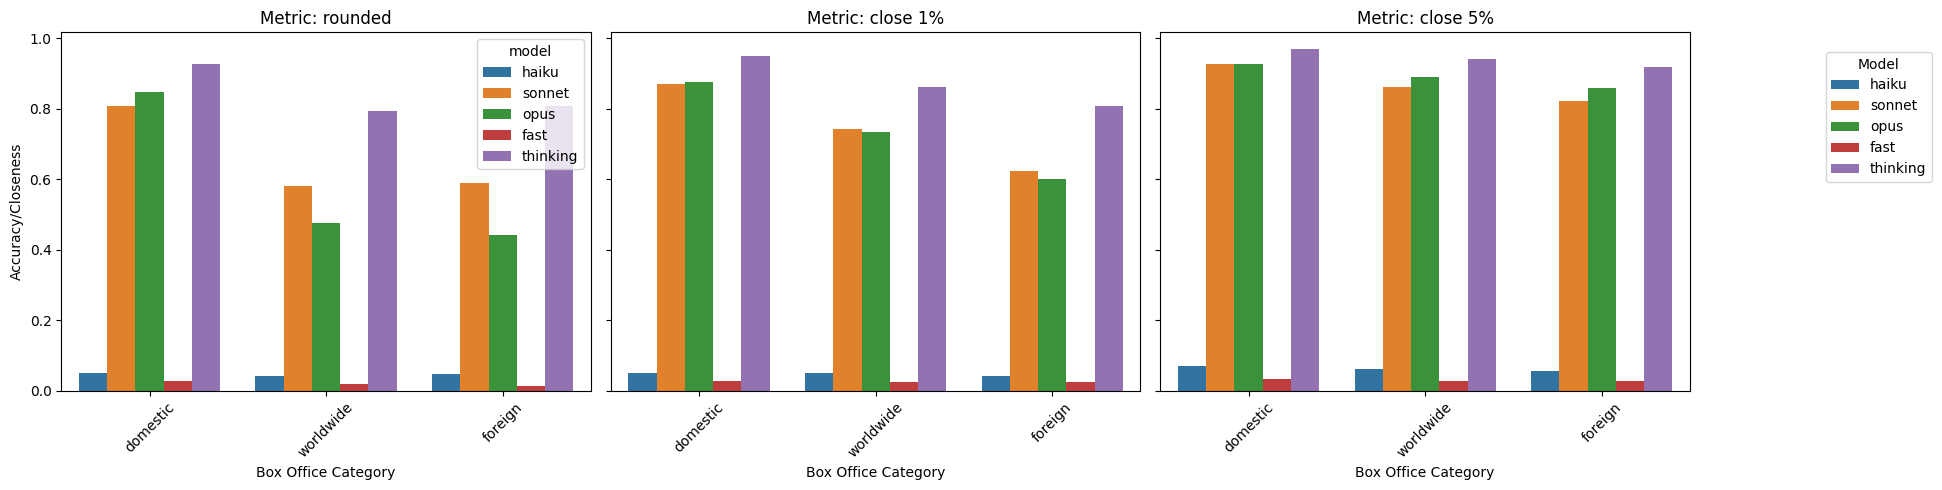

In [ ]:
data_for_plot = []
for model, metrics in boxoffice_evals.items():
    for metric_name, categories in metrics.items():
        for category, value in categories.items():
            data_for_plot.append({'model': model, 'metric': metric_name, 'category': category, 'value': value})

plot_df = pd.DataFrame(data_for_plot)

# Order metrics for consistent plotting
metric_order = ['rounded', 'close_1%', 'close_5%']
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=metric_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, metric in enumerate(metric_order):
    sns.barplot(data=plot_df[plot_df['metric'] == metric], x='category', y='value', hue='model', ax=axes[i])
    axes[i].set_title(f'Metric: {metric.replace("_", " ")}')
    axes[i].set_ylabel('Accuracy/Closeness' if i == 0 else '')
    axes[i].set_xlabel('Box Office Category')
    axes[i].tick_params(axis='x', rotation=45)
    if i > 0: # Remove duplicate legends
      axes[i].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model', loc='upper right', bbox_to_anchor=(1.08, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make space for legend
plt.show()

## VES awards

### Canonical data

In [111]:
ves_pdf = pd.read_csv(eval_loc + 'ves_awards/golden_set_ves_classified.tsv', sep = '\t')
ves_eval_cols = ['year', 'title', '# of nominations', 'outstanding']
ves_eval_pdf = ves_pdf.query('media_type == "film" and year >= 2019 and year <= 2024')[ves_eval_cols]
ves_eval_pdf = clean_award_data(ves_eval_pdf)

In [1]:
claude = {'opus':pd.DataFrame()}
gemini = {}
claude['opus'] = pd.read_csv(eval_loc + 'ves_awards/claude_opus_45_ves_y6.tsv', sep = '\t').query('year >= 2019 and year <= 2024')
gemini['flash'] = pd.read_csv(eval_loc + 'ves_awards/gemini_flash_3_ves_y6.tsv', sep = '\t').query('year >= 2019 and year <= 2024')

NameError: name 'pd' is not defined

In [113]:
for key, df in claude.items():
  df = clean_award_data(df)
  df['# of nominations'] = df['# of nominations'].fillna(0).astype(pd.Int64Dtype())

for key, df in gemini.items():
  df = clean_award_data(df)

In [120]:
merges = {}
merges['opus'] = claude['opus'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))

### Eval

In [117]:
ves_default = {'nom_count':0.0,
               'outstanding': 0.0}
ves_evals = { }
ves_evals = {'haiku':copy.deepcopy(ves_default),
              'sonnet':copy.deepcopy(ves_default),
              'opus':copy.deepcopy(ves_default),
              'fast':copy.deepcopy(ves_default),
              'thinking':copy.deepcopy(ves_default)
                      }

In [135]:
test_df =merge_df.loc[merge_df['outstanding_eval'].notnull()]
test_df.loc[test_df['outstanding_eval'] != test_df['outstanding_student']]

,year,title,# of nominations_student,outstanding_student,# of nominations_eval,outstanding_eval
21,2024,wicked,1,NaN,1,outstanding
56,2022,jurassic world: dominion,<NA>,NaN,2,outstanding
67,2022,i wanna dance with somebody,<NA>,NaN,1,supporting


In [137]:
models = ['opus']
for model in models:
  merge_df = merges[model]
  ves_evals[model]['nom_count'] = (merge_df['# of nominations_eval'] == merge_df['# of nominations_student']).sum() / len(merge_df)
  ves_evals[model]['outstanding'] = (merge_df['outstanding_eval'] == merge_df['outstanding_student']).sum() / ves_eval_pdf['outstanding'].notnull().sum()

In [138]:
ves_evals

{'haiku': {'nom_count': 0, 'outstanding': 0},
 'sonnet': {'nom_count': 0, 'outstanding': 0},
 'opus': {'nom_count': np.float64(0.7894736842105263),
  'outstanding': np.float64(0.9473684210526315)},
 'fast': {'nom_count': 0, 'outstanding': 0},
 'thinking': {'nom_count': 0, 'outstanding': 0}}